In [21]:
import os
import pandas as pd
import numpy as np
from transformers import BertTokenizerFast, BertModel
import torch
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
from tqdm import tqdm
tqdm.pandas()

### SAT Rewrites

In [2]:
sat_rewrites_dir = "../data/rewrites/sat_full/cleaned/"

sat_rew = []

for fname in os.listdir(sat_rewrites_dir):
    if fname.endswith(".csv"):
        path = os.path.join(sat_rewrites_dir, fname)
        df = pd.read_csv(path)
        sat_rew.append(df)

In [3]:
for i,rew in enumerate(sat_rew):
    print(f"sat {i+1}, content preserved - True: {rew['content_preserved'].value_counts().iloc[0]} False: {rew['content_preserved'].value_counts().iloc[1]}")

sat 1, content preserved - True: 19920 False: 54
sat 2, content preserved - True: 19936 False: 38
sat 3, content preserved - True: 19937 False: 37
sat 4, content preserved - True: 19298 False: 676
sat 5, content preserved - True: 19867 False: 107
sat 6, content preserved - True: 19183 False: 791


In [4]:
mean_not_preserved = sum([x["content_preserved"].value_counts().iloc[1] for x in sat_rew])/len(sat_rew)
print(f"Mean content not preserved SAT Rewrites - {mean_not_preserved:.2f}")

Mean content not preserved SAT Rewrites - 283.83


### No Description Rewrites

In [5]:
no_desc_rewrites_dir = "../data/rewrites/no_desc/cleaned/no_desc_rewritten_0_cleaned.csv"
df_no_desc = pd.read_csv(no_desc_rewrites_dir)

/var/folders/lm/psfj50g95wgczw9z2l6zf32m0000gn/T/ipykernel_77168/3774473763.py:2: DtypeWarning: Columns (375) have mixed types. Specify dtype option on import or set low_memory=False.
  df_no_desc = pd.read_csv(no_desc_rewrites_dir)


In [6]:
print(
    f"no_desc — "
    f"True: {df_no_desc['content_preserved_0'].value_counts().iloc[0]}, False: {df_no_desc['content_preserved_0'].value_counts().iloc[1]}")

no_desc — True: 20409, False: 329


### Embeddings distance OG x Rewrites

In [7]:
og_text = sat_rew[0].iloc[0]['text']
rew = []

for r in sat_rew:
    rew.append(r[r['text'] == og_text]['rewritten_text'].iloc[0])

In [8]:
og_text_prompt = sat_rew[0].iloc[0]['prompt_name']
print(og_text_prompt)
og_text_ses = sat_rew[0].iloc[0]['economically_disadvantaged']
print(og_text_ses)

Summer projects
0


In [9]:
rew_0 = sat_rew[0].copy()

filtered_texts = rew_0[(rew_0['prompt_name'] == og_text_prompt) & (rew_0["economically_disadvantaged"] == og_text_ses)]
sample_text = filtered_texts.sample(1, random_state=42)['text'].iloc[0]

In [10]:
device = torch.device('mps') if (torch.backends.mps.is_available()) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').eval().to(device)

def get_embeddings(text: str) -> np.ndarray:
    """
    Run one text through BERT, return the [CLS] embedding as a numpy vector.
    """
    inputs = tokenizer(text,
                       return_tensors='pt',
                       padding=True,
                       truncation=True,
                       max_length=512)
    # move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    # [batch=1, seq, dim] → pick CLS token embedding
    cls_emb = outputs.last_hidden_state[0, 0, :]
    return cls_emb.cpu().numpy()

def embed_text(text):
    if text is None:
        text = ""
    emb = get_embeddings(text)
    return np.asarray(emb).reshape(1, -1)

In [ ]:
original_emb = embed_text(og_text)
sample_emb = embed_text(sample_text)
rew_emb = [embed_text(r) for r in rew]

In [18]:
original_emb = original_emb.reshape(1, -1)
sample_emb   = sample_emb.reshape(1, -1)

rew_emb = np.vstack([r.reshape(1, -1) for r in rew_emb])  # (6, d)

In [ ]:
# Distance to random same-SES, same-prompt sample
dist_og_sample = cosine_distances(original_emb, sample_emb)[0, 0]

# Distances to each rewrite
dist_og_rew = cosine_distances(original_emb, rew_emb).flatten()

In [20]:
print(f"Distance (original → random sample): {dist_og_sample:.4f}")

for i, d in enumerate(dist_og_rew, 1):
    print(f"Distance (original → rewrite {i}): {d:.4f}")

print(f"\nMean distance (original → rewrites): {dist_og_rew.mean():.4f}")

Distance (original → random sample): 0.1600
Distance (original → rewrite 1): 0.0613
Distance (original → rewrite 2): 0.1034
Distance (original → rewrite 3): 0.1223
Distance (original → rewrite 4): 0.1041
Distance (original → rewrite 5): 0.0685
Distance (original → rewrite 6): 0.1497

Mean distance (original → rewrites): 0.1016


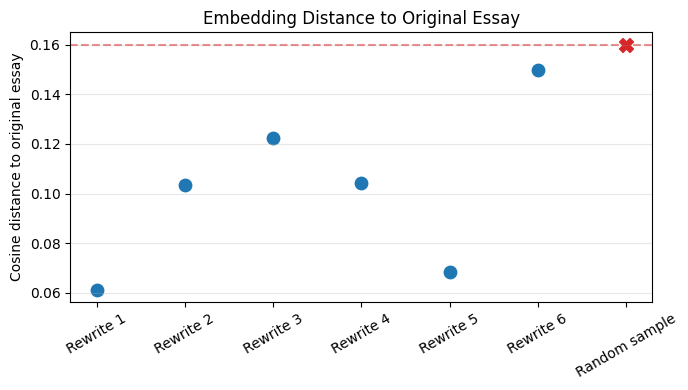

In [27]:
labels_rew = [f"Rewrite {i}" for i in range(1, 7)]

plt.figure(figsize=(7, 4))

plt.scatter(
    labels_rew,
    dist_og_rew,
    s=80,
    color="tab:blue",
    label="Rewrites"
)

plt.scatter(
    ["Random sample"],
    [dist_og_sample],
    s=100,
    color="tab:red",
    marker="X",
    label="Random (same SES & prompt)"
)

plt.axhline(
    dist_og_sample,
    linestyle="--",
    color="tab:red",
    alpha=0.5
)

plt.ylabel("Cosine distance to original essay")
plt.title("Embedding Distance to Original Essay")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()